<a href="https://colab.research.google.com/github/IIC1005/ML/blob/main/Experiencia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!wget -O datos.zip https://www.dropbox.com/scl/fi/g0eundazlz60mroj6wjgp/ML_2025-2.zip?rlkey=ftmzo7843ibj4w4u0k3ogo3pr&dl=1
!unzip -j datos.zip

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

import ipywidgets as widgets
from IPython.display import display, clear_output
from tqdm.notebook import tqdm

# 1. Cargar Datos
Utilizamos la función `get_mnist()`, la cual genera 4 arreglos a partir del dataset publico [MNIST](https://www.kaggle.com/datasets/hojjatk/mnist-dataset)

`train_images`: arreglo de 60.000 números dibujados, cada uno como vector de largo 784 \
`train_labels`: arreglo de 60.000 _labels_ (número correspondiente a la imagen), cada uno como vector de largo 10 \
`test_images`: arreglo de 10.000 números dibujados, cada uno como vector de largo 784 para validar el modelo \
`test_labels`: arreglo de 10.000 _labels_ (número correspondiente a la imagen), cada uno como vector de largo 10  para validar el modelo

In [ ]:
from data import get_mnist  # type: ignore[misc]

train_images, train_labels, test_images, test_labels = get_mnist()

Para ver ejemplos de números del dataset, ejecuta la siguiente celda varias veces.

In [ ]:
# @title
import random

i = random.randint(0, len(train_images))

img, label = train_images[i], train_labels[i]

fig, ax = plt.subplots(figsize=(8, 4))

ax.imshow(img.reshape(28, 28), cmap="Greys")
ax.axis("off")
ax.set_title(f"Valor Label : {label.argmax()}")

plt.tight_layout()
plt.show()


# 2. Pesos Iniciales e Hiperparámetros

Necesitamos crear dos matrices de pesos: \
`w_i_h`: Matriz que almacena los pesos (_weights_) desde la capa de _input_ hacia la capa _hidden_ \
`w_h_o`: Matriz que almacena los pesos (_weights_) desde la capa _hidden_ hacia la capa de _output_

Para esto utilizamos la función `np.random.uniform(low, high, size)`, la cual genera una matriz de tamaño `size` con valores aleatorios entre `low` y `high`.

_Para convertir un vector `b` de tamaño `n` a `m` calculamos `A⋅b`, donde `A` es una matriz de forma `(n, m)`_

In [ ]:
# Pesos - Input (784) - Hidden (20)
w_i_h = np.random.uniform(-0.5, 0.5, (20, 784))

# Pesos - Hidden (20) - Output (10)
w_h_o = np.random.uniform(-0.5, 0.5, (10, 20))

Luego, definimos dos hiperparámetros que nuestro modelo utilizara durante el entrenamiento: \
`epochs`: `???` \
`learn_rate`: `???`

_Deberán explicar que son estos hiperparámetros y sus efectos mas adelante_

In [ ]:
epochs = 3
learn_rate = 0.01

# 3. Entrenamiento

El entrenamiento de la red neuronal se divide en 3 pasos principales, los cuales se repiten por cada par `(imagen, label)`

### Forward Propagation

- Este paso se encarga de predecir el vector de _output_ a partir de un _input_.
- Realiza las operaciones matriciales desde el inicio de la red hasta el final _(forward)_.
- El resultado será  la predicción de la red, un vector de probabilidades de largo 10, donde cada entrada corresponde a un número.

_Para multiplicar matrices utilizamos el operador `@` implementado por `numpy`_

### Error

- En este paso se calcula el [error cuadratico medio](https://es.wikipedia.org/wiki/Error_cuadr%C3%A1tico_medio) (MSE) entre el vector predicho y el _label_ real de la imagen.
- Tambien revisamos si la prediccion fue correcta para luego obtener la _accuracy:_ `correctas / total`

### Backpropagation

* Este es el paso mas importante y "complejo" del entrenamiento.
* Calcula cuanto influye cada conexión sobre el error final.
* Ajusta los pesos de la red desde el final de esta hasta su inicio _(backwards)_, con el fin de minimizar el error.
* Para esto se utiliza [descenso de gradiente](https://es.wikipedia.org/wiki/Descenso_del_gradiente).

In [ ]:
for epoch in range(epochs):
  n_correct = 0
  # for img, l in zip(train_images, train_labels):                               # se itera por cada par (imagen, label)
  for img, l in tqdm(zip(train_images, train_labels), total=len(train_images)):  # pero este tiene barra de progreso (cool)
    img.shape += (1,)
    l.shape += (1,)

    # 1. Forward prop. input -> hidden                                           # 1. Forward prop. input -> hidden
    h_pre = w_i_h @ img                                                          # Multiplica input con sus pesos
    h = 1 / (1 + np.exp(-h_pre))                                                 # Se pasa el vector resultante por la función de activción

    # 2. Forward prop. hidden -> output                                          # 2. Forward prop. hidden -> output
    o_pre = w_h_o @ h                                                            # Multiplica hidden con sus pesos
    o = 1 / (1 + np.exp(-o_pre))                                                 # Se pasa el vector resultante por la función de activción (esta es la prediccion!)

    # 3. Cost / Error calculation                                                # 3. Cost / Error calculation
    e = np.mean((o - l) ** 2)                                                    # Error cuadrático medio (función a minimizar)
    n_correct += int(np.argmax(o) == np.argmax(l))                               # Contar correctas

    # 4. Backprop. output -> hidden (cost function derivative)                   # 4. Backprop. output -> hidden (cost function derivative)
    delta_o = o - l                                                              # Derivada del MSE (descenso de gradiente)
    w_h_o += -learn_rate * delta_o @ h.T                                         # Ajuste de pesos

    # 5. Backprop. hidden -> input (activation function derivative)              # 5. Backprop. hidden -> input (activation function derivative)
    delta_h = w_h_o.T @ delta_o * (h * (1 - h))                                  # Se propaga delta_o y se multiplica por la derivada de la función de activacion
    w_i_h += -learn_rate * delta_h @ img.T                                       # Ajuste de pesos

  print(f"Acc: {round((n_correct / len(train_images)) * 100, 2)}%")              # Accuracy: total_correctas / total_imagenes

# 4. Validación (Actividad)

Nuestro modelo funciona bien en teoria, con una _accuracy_ de sobre 90%. Sin embargo, este valor se obtiene al evaluar el modelo a partir de las imágenes con las que se entrenó y, por lo tanto, ya conoce. Para validar, debemos utilizar imágenes que la red nunca ha visto.

En esta actividad, deberan calcular la _accuracy_ a partir del dataset de testeo `test_images`

_hint: el modelo ya esta entrenado, por lo que no deben ajustar ningún peso_



In [ ]:
n_correct = 0
for img, l in zip(test_images, test_labels):
  img.shape += (1,)
  l.shape += (1,)

  # Completar

# 5. A Jugar (Actividad)

Una vez validado el modelo, podemos entregarle nuevos numeros y ver si predice de manera correcta. Para esto definimos la siguiente función que realiza el proceso de _forward propagation_ y grafica los resultados.

In [ ]:
def test_image(i):
  clear_output(wait=True)
  display(test_widget)

  img = get_img(i)

  # Forward prop. input -> hidden
  h_pre = w_i_h @ img
  h = 1 / (1 + np.exp(-h_pre))

  # Forward prop. hidden -> output
  o_pre = w_h_o @ h
  o = 1 / (1 + np.exp(-o_pre))

  plot_results(img, o)

  test_widget.value = ""

y algunas funciones auxiliares para graficar.

In [ ]:
# @title
def get_img(i):
  i = i.value
  img = np.zeros((28, 28), dtype=np.float32)
  for i, v in enumerate(i.split(",")):
    img[i // 28, i % 28] = float(v)

  return img.reshape(784, 1)


def plot_results(img, output):
  probs = output.ravel()
  prediction = probs.argmax()

  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))

  ax1.imshow(img.reshape(28, 28), cmap="Greys")
  ax1.axis("off")
  ax1.set_title(f"Predicción: {prediction}")

  digits = np.arange(10)
  ax2.barh(digits, probs, color="skyblue")
  ax2.set_yticks(digits)
  ax2.set_xlabel("Confianza")
  ax2.set_ylabel("Dígito")
  ax2.invert_yaxis()
  ax2.set_xlim(0, 1)

  ax2.barh(prediction, probs[prediction], color="orange")

  plt.tight_layout()
  plt.show()


test_widget = widgets.Text(
  value='',
  description='Input: ',
  disabled=False
)

test_widget.on_submit(test_image)

Para probar el modelo, ejecuta la siguiente celda, genera un número con esta [herramienta](https://damiangubbins.github.io/Draw-Tool/), pega el resultado abajo y presiona `ENTER` para realizar una predicción.

_En el entregable debes subir dos imagenes, una donde el modelo realiza una prediccion correcta y una donde se equivoque miserablemente_

In [ ]:
display(test_widget)

# 6. Ajuste de Hiperparámetros (Actividad)

Anteriormente, se mencionaron dos hiperparámetros: `epochs` y `learn_rate`. En esta actividad deberan entrenar dos modelos nuevos, variando ambos hiperparámetros, para graficar el error `e` a lo largo del entrenamiento. Tambien pueden modificar el tamaño de la capa _hidden_.

_En el entregable deberan agregar una breve explicacion de que hace cada hiperparametro_

Ejemplo de como se debería ver el gráfico: _(no debe ser exactamente igual)_

**Si debe incluir los parámetros en el título del gráfico.**

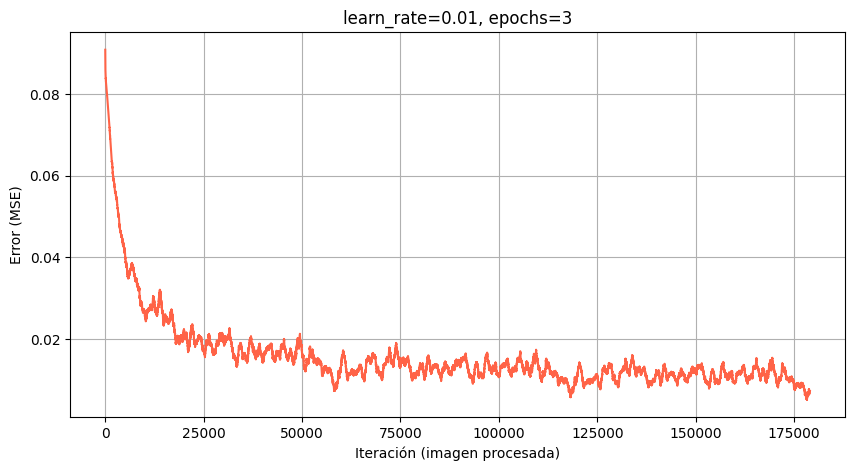

### Modelo 1

In [ ]:
# Modificar epochs, learn_rate y tamaño de la capa hidden

w_i_h = np.random.uniform(-0.5, 0.5, (20, 784))
w_h_o = np.random.uniform(-0.5, 0.5, (10, 20))

epochs = 3
learn_rate = 0.01

In [ ]:
# Entrenar modelo

errores_1 = []

# Completar

In [ ]:
# Graficar
if errores_1:
    n = 500
    errores_suavizados = np.convolve(errores_1, np.ones(n)/n, mode='valid')
    plt.plot(errores_suavizados)
    # Completar (mostrar en el título los hiperparametros)

    plt.xlabel("Iteración (imagen procesada)")
    plt.ylabel("Error (MSE)")
    plt.grid(True)
    plt.show()

### Modelo 2


In [ ]:
# Modificar epochs, learn_rate y tamaño de la capa hidden

w_i_h = np.random.uniform(-0.5, 0.5, (20, 784))
w_h_o = np.random.uniform(-0.5, 0.5, (10, 20))

epochs = 3
learn_rate = 0.01

In [ ]:
# Entrenar modelo

errores_2 = []

# Completar

In [ ]:
# Graficar
if errores_2:
    n = 500
    errores_suavizados = np.convolve(errores_2, np.ones(n)/n, mode='valid')
    plt.plot(errores_suavizados)
    # Completar (mostrar en el título los hiperparametros elegidos)

    plt.xlabel("Iteración (imagen procesada)")
    plt.ylabel("Error (MSE)")
    plt.grid(True)
    plt.show()

# Extra: Implementación sin `numpy`

In [ ]:
# @title
import random


def random_uniform(low, high, size):
    """Genera una matriz de tamaño 'size' con valores aleatorios uniformemente distribuidos entre 'low' y 'high'."""
    m, n = size
    arr = []
    for i in range(m):
        row = []
        for j in range(n):
            row.append(random.uniform(low, high))
        arr.append(row)

    return arr


def zeros(size):
    """Genera una matriz de tamaño 'size' llena de ceros."""
    m, n = size
    arr = []
    for i in range(m):
        row = []
        for j in range(n):
            row.append(0.0)
        arr.append(row)

    return arr


def __matadd__(a, b):
    """Suma de matrices `a` y `b`."""
    m, n = len(a), len(a[0])
    result = zeros((m, n))

    for i in range(m):
        for j in range(n):
            result[i][j] = a[i][j] + b[i][j]

    return result


def __add__(a, b):
    """Suma `a` a cada elemento de `b`."""
    m, n = len(b), len(b[0])
    result = zeros((m, n))

    for i in range(m):
        for j in range(n):
            result[i][j] = a + b[i][j]

    return result


def __matsub__(a, b):
    """Resta de matrices `a` y `b`."""
    m, n = len(a), len(a[0])
    result = zeros((m, n))

    for i in range(m):
        for j in range(n):
            result[i][j] = a[i][j] - b[i][j]

    return result


def __sub__(a, b):
    """Resta `a` a cada elemento de `b`."""
    m, n = len(b), len(b[0])
    result = zeros((m, n))

    for i in range(m):
        for j in range(n):
            result[i][j] = a - b[i][j]

    return result


def __matmul__(a, b):
    """Multiplicación de matrices `a` y `b`."""
    m, n = len(a), len(b[0])
    p = len(b)
    result = zeros((m, n))

    for i in range(m):
        for j in range(n):
            for k in range(p):
                result[i][j] += a[i][k] * b[k][j]

    return result


def __mul__(a, b):
    """Multiplicación elemento a elemento de matriz `a` y matriz `b`."""
    m, n = len(a), len(a[0])
    result = zeros((m, n))

    for i in range(m):
        for j in range(n):
            result[i][j] = a[i][j] * b[i][j]

    return result


def __matscale__(a, b):
    """Multiplica cada elemento de la matriz `b` por el escalar `a`."""
    m, n = len(b), len(b[0])
    result = zeros((m, n))

    for i in range(m):
        for j in range(n):
            result[i][j] = a * b[i][j]

    return result


def __div__(a, b):
    """Divide el escalar `a` por cada elemento de la matriz `b`."""
    m, n = len(b), len(b[0])
    result = zeros((m, n))

    for i in range(m):
        for j in range(n):
            result[i][j] = a / b[i][j]

    return result


def __pow__(a, b):
    """Eleva cada elemento de la matriz `a` a la potencia `b`."""
    m, n = len(a), len(a[0])
    result = zeros((m, n))

    for i in range(m):
        for j in range(n):
            result[i][j] = a[i][j] ** b

    return result


def exp(a):
    """Calcula el exponencial de cada elemento de la matriz `a`."""
    e = 2.718281828459045
    m, n = len(a), len(a[0])
    result = zeros((m, n))

    for i in range(m):
        for j in range(n):
            result[i][j] = e ** a[i][j]

    return result


def mean(a):
    """Calcula la media de los elementos de la matriz `a`."""
    m, n = len(a), len(a[0])

    total = 0.0
    for i in range(m):
        for j in range(n):
            total += a[i][j]

    return total / (m * n)


def argmax(a):
    """Devuelve el índice del mayor elemento de la matriz `a`."""
    m, n = len(a), len(a[0])
    max_value = a[0][0]
    max_index = (0, 0)

    for i in range(m):
        for j in range(n):
            if a[i][j] > max_value:
                max_value = a[i][j]
                max_index = (i, j)

    return max_index


def transpose(a):
    """Transpone la matriz `a`."""
    m, n = len(a), len(a[0])
    result = zeros((n, m))

    for i in range(m):
        for j in range(n):
            result[j][i] = a[i][j]

    return result


In [ ]:
# @title
w_i_h = random_uniform(-0.5, 0.5, (20, 784))
w_h_o = random_uniform(-0.5, 0.5, (10, 20))

epochs = 3
learn_rate = 0.01

In [ ]:
# @title
if False:  # Cambiar esto a 'True' para entrenar el modelo
  for epoch in range(epochs):
    n_correct = 0
    for img, l in tqdm(zip(train_images, train_labels), total=len(train_images)):
      img.shape += (1,)
      l.shape += (1,)

      # 1. Forward prop. input -> hidden
      h_pre = __matmul__(w_i_h, img)
      h = __div__(1, (__add__(1, exp(__matscale__(-1, h_pre)))))

      # 2. Forward prop. hidden -> output
      o_pre = __matmul__(w_h_o, h)
      o = __div__(1, (__add__(1, exp(__matscale__(-1, o_pre)))))

      # 3. Cost / Error calculation
      e = mean(__pow__(__matsub__(o, l), 2))
      n_correct += int(argmax(o) == argmax(l))

      # 4. Backprop. output -> hidden (cost function derivative)
      delta_o = __matsub__(o, l)
      w_h_o = __matadd__(w_h_o, __matscale__(-learn_rate, __matmul__(delta_o, transpose(h))))

      # 5. Backprop. hidden -> input (activation function derivative)
      delta_h = __mul__(__matmul__(transpose(w_h_o), delta_o), __mul__(h, __sub__(1, h)))
      w_i_h = __matadd__(w_i_h, __matscale__(-learn_rate, __matmul__(delta_h,  transpose(img))))

    print(f"Acc: {round((n_correct / len(train_images)) * 100, 2)}%")